<a href="https://colab.research.google.com/github/Vane-UNCP/tecemer-lab1/blob/main/SEMANA6/Ejercicio_04b_RNN_Series_Temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4b — Redes Neuronales Recurrentes (RNN): Series Temporales
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Genera sus propios datos (una serie temporal sintética con tendencia y estacionalidad), así que no depende de ninguna descarga externa.

**Objetivo:** entender el flujo completo de pronóstico con redes recurrentes: por qué el orden temporal importa, cómo convertir una serie en pares de entrenamiento (ventaneo), por qué la partición debe ser secuencial (nunca aleatoria), y cómo comparar un modelo LSTM contra un baseline honesto.

Framework: **TensorFlow/Keras** (alternamos con PyTorch entre notebooks, como en la práctica profesional real).

## 0. Configuración inicial

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Generar una serie temporal sintética

Simulamos 3 años de una variable diaria (por ejemplo, temperatura o demanda de un servicio) con tres componentes: **tendencia** (crecimiento lento), **estacionalidad** (ciclo anual) y **ruido** (variación aleatoria) — la misma estructura que aparece en series reales como el clima de Lima.

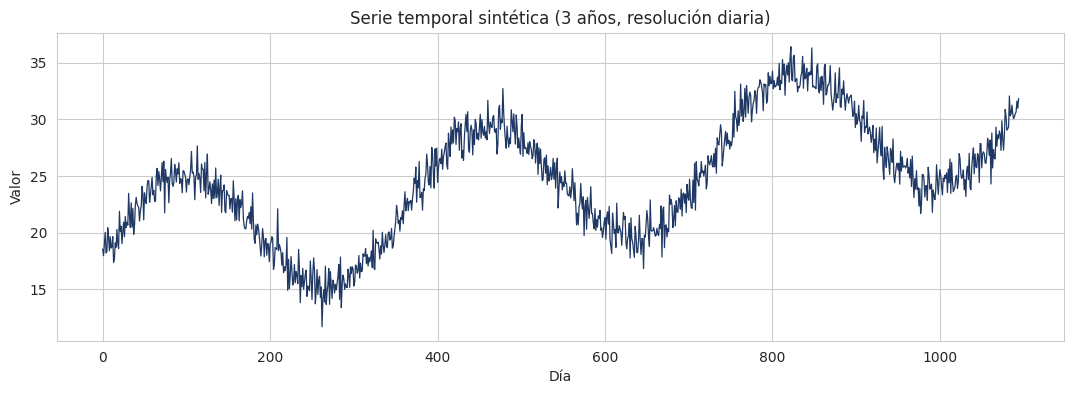

In [3]:
N_DIAS = 3 * 365
t = np.arange(N_DIAS)

tendencia = 0.012 * t
estacionalidad = 6 * np.sin(2 * np.pi * t / 365)
ruido = np.random.normal(0, 1.1, N_DIAS)

serie = 18 + tendencia + estacionalidad + ruido

plt.figure(figsize=(13, 4))
plt.plot(t, serie, linewidth=0.9, color="#1F3864")
plt.title("Serie temporal sintética (3 años, resolución diaria)")
plt.xlabel("Día"); plt.ylabel("Valor")
plt.show()

## 2. ¿Por qué una RNN y no un MLP o una CNN "planas"?

En una serie temporal, **el orden importa**: el valor de mañana depende del de hoy y de los días anteriores, en ese orden. Una capa `Dense` normal trata cada entrada como independiente de las demás — no tiene noción de "antes" y "después".

Una **RNN** procesa la secuencia paso a paso, manteniendo un **estado oculto** que se actualiza en cada paso temporal y funciona como una "memoria" de lo visto hasta ese momento. La variante **LSTM** (Long Short-Term Memory) agrega compuertas internas (de olvido, entrada y salida) que le permiten decidir qué información conservar a largo plazo y qué descartar — esto resuelve el problema del "gradiente que desaparece" que limita a las RNN simples cuando la secuencia es larga.

## 3. Ventaneo: convertir la serie en pares (X, y)

Una red no recibe "la serie completa" de una vez para predecir un solo valor futuro — se le muestra una **ventana** de los últimos N valores, y aprende a predecir el siguiente.

X: (1081, 14)  y: (1081,)


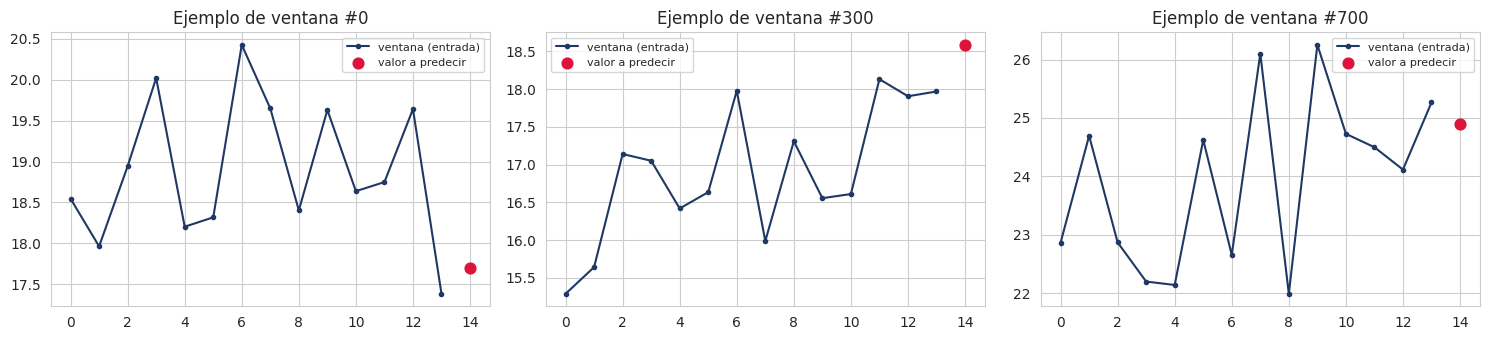

In [4]:
def crear_ventanas(serie, ventana):
    X, y = [], []
    for i in range(len(serie) - ventana):
        X.append(serie[i:i + ventana])
        y.append(serie[i + ventana])
    return np.array(X), np.array(y)

VENTANA = 14  # usamos los últimos 14 días para predecir el día siguiente
X, y = crear_ventanas(serie, VENTANA)
print("X:", X.shape, " y:", y.shape)

fig, ejes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, i in zip(ejes, [0, 300, 700]):
    ax.plot(range(VENTANA), X[i], marker="o", markersize=3, color="#1F3864", label="ventana (entrada)")
    ax.scatter([VENTANA], [y[i]], color="crimson", s=60, zorder=5, label="valor a predecir")
    ax.set_title(f"Ejemplo de ventana #{i}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Partición secuencial (¡NO aleatoria!)

**Importante:** con series temporales, `train_test_split` con mezcla aleatoria produciría una fuga de información (el modelo "vería" el futuro durante el entrenamiento). La partición debe respetar el orden cronológico: el conjunto de prueba son siempre los días **más recientes**.

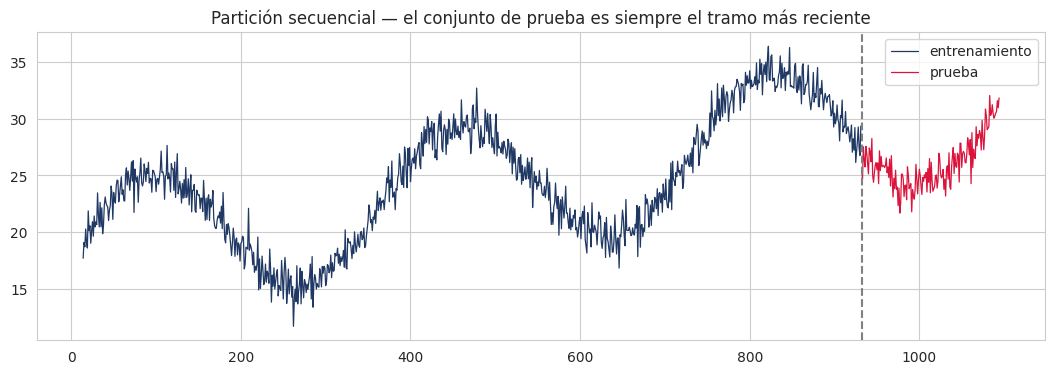

Entrenamiento: 918 ventanas | Prueba: 163 ventanas


In [5]:
corte = int(len(X) * 0.85)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

plt.figure(figsize=(13, 4))
plt.plot(t[VENTANA:VENTANA+corte], y_train, color="#1F3864", label="entrenamiento", linewidth=0.9)
plt.plot(t[VENTANA+corte:], y_test, color="crimson", label="prueba", linewidth=0.9)
plt.axvline(t[VENTANA+corte], color="gray", linestyle="--")
plt.title("Partición secuencial — el conjunto de prueba es siempre el tramo más reciente")
plt.legend()
plt.show()

print(f"Entrenamiento: {len(X_train)} ventanas | Prueba: {len(X_test)} ventanas")

## 5. Escalado

In [6]:
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train).reshape(-1, VENTANA, 1)
X_test_esc = escalador.transform(X_test).reshape(-1, VENTANA, 1)

print("Forma final para la LSTM:", X_train_esc.shape, "-> (muestras, pasos_de_tiempo, n_variables)")

Forma final para la LSTM: (918, 14, 1) -> (muestras, pasos_de_tiempo, n_variables)


## 6. Baseline ingenuo

Antes de entrenar cualquier red, establecemos un punto de comparación honesto: predecir que **mañana será igual a hoy** (persistencia).

In [7]:
prediccion_baseline = X_test[:, -1]  # último valor de cada ventana
mae_baseline = mean_absolute_error(y_test, prediccion_baseline)
print(f"MAE del baseline ingenuo (persistencia): {mae_baseline:.3f}")

MAE del baseline ingenuo (persistencia): 1.213


## 7. Construir y entrenar la LSTM

In [8]:
modelo_lstm = keras.Sequential([
    layers.Input(shape=(VENTANA, 1)),
    layers.LSTM(32, activation="tanh"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
modelo_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

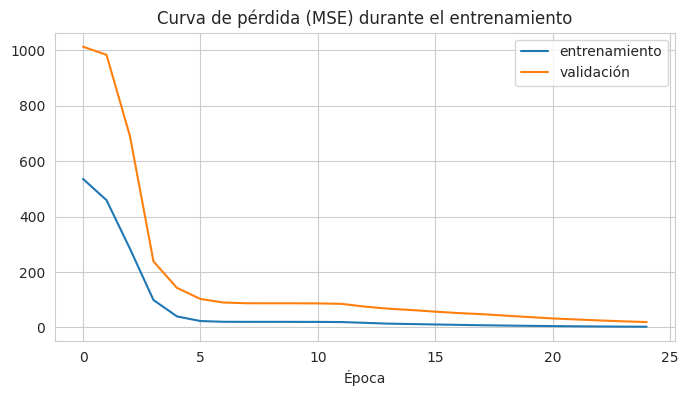

In [9]:
historial = modelo_lstm.fit(
    X_train_esc, y_train, epochs=25, batch_size=32,
    validation_split=0.15, verbose=0,
)

plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"], label="entrenamiento")
plt.plot(historial.history["val_loss"], label="validación")
plt.title("Curva de pérdida (MSE) durante el entrenamiento")
plt.xlabel("Época"); plt.legend()
plt.show()

## 8. Evaluar y visualizar el pronóstico

MAE de la LSTM en prueba:      1.158
MAE del baseline en prueba:    1.213


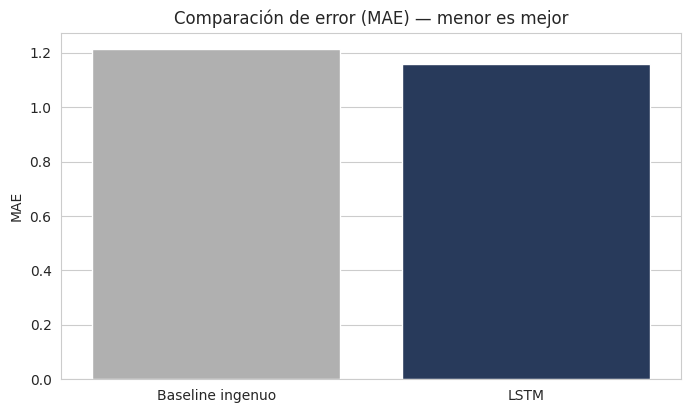

In [10]:
y_pred = modelo_lstm.predict(X_test_esc, verbose=0).flatten()
mae_lstm = mean_absolute_error(y_test, y_pred)

print(f"MAE de la LSTM en prueba:      {mae_lstm:.3f}")
print(f"MAE del baseline en prueba:    {mae_baseline:.3f}")

plt.figure(figsize=(8, 4.5))
sns.barplot(x=["Baseline ingenuo", "LSTM"], y=[mae_baseline, mae_lstm],
            hue=["Baseline ingenuo", "LSTM"], palette=["#B0B0B0", "#1F3864"], legend=False)
plt.title("Comparación de error (MAE) — menor es mejor")
plt.ylabel("MAE")
plt.show()

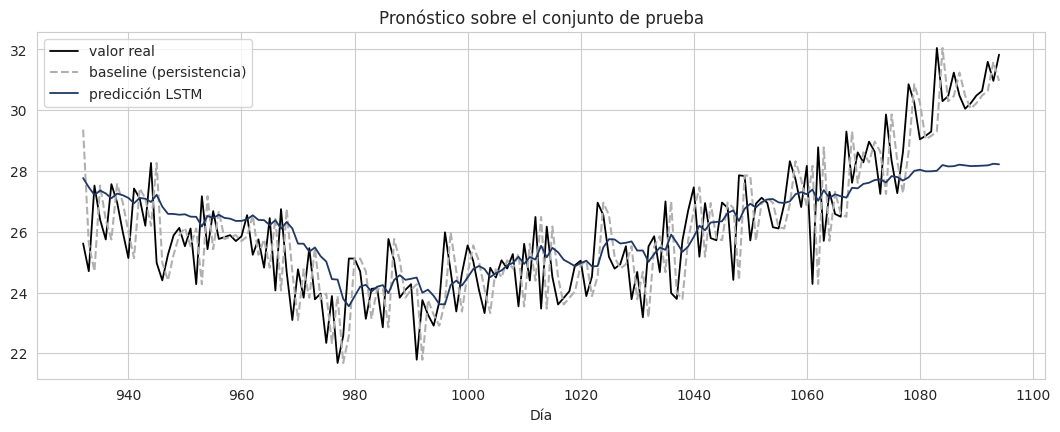

In [11]:
dias_test = t[VENTANA + corte:]

plt.figure(figsize=(13, 4.5))
plt.plot(dias_test, y_test, label="valor real", color="black", linewidth=1.3)
plt.plot(dias_test, prediccion_baseline, label="baseline (persistencia)", color="#B0B0B0", linestyle="--")
plt.plot(dias_test, y_pred, label="predicción LSTM", color="#1F3864", linewidth=1.3)
plt.title("Pronóstico sobre el conjunto de prueba")
plt.xlabel("Día"); plt.legend()
plt.show()

## 9. Pronóstico recursivo a varios pasos

Hasta ahora predijimos un solo paso adelante. Para pronosticar varios días seguidos, se usa cada predicción como parte de la ventana de entrada del siguiente paso (pronóstico recursivo) — el error tiende a acumularse, por lo que la incertidumbre crece con el horizonte.

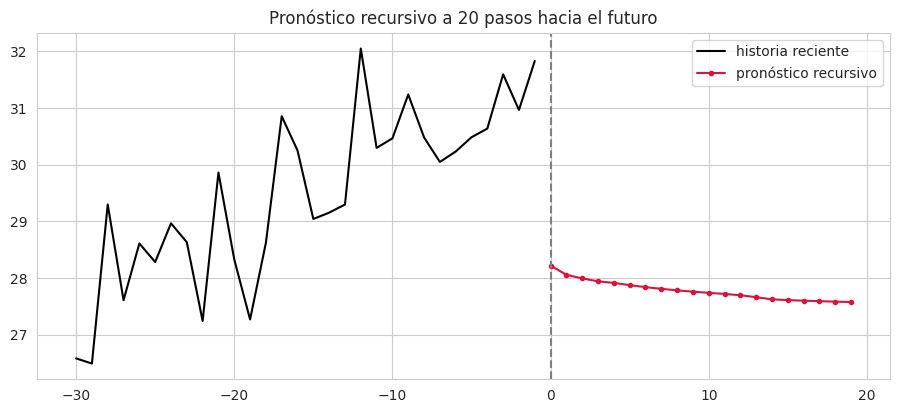

In [12]:
def pronostico_recursivo(modelo, ventana_inicial, escalador, n_pasos):
    ventana_actual = ventana_inicial.copy()
    predicciones = []
    for _ in range(n_pasos):
        entrada_esc = escalador.transform(ventana_actual.reshape(1, -1)).reshape(1, VENTANA, 1)
        siguiente = modelo.predict(entrada_esc, verbose=0)[0, 0]
        predicciones.append(siguiente)
        ventana_actual = np.append(ventana_actual[1:], siguiente)
    return np.array(predicciones)

N_PASOS_FUTUROS = 20
ventana_inicial = X_test[-1]
pronostico = pronostico_recursivo(modelo_lstm, ventana_inicial, escalador, N_PASOS_FUTUROS)

plt.figure(figsize=(11, 4.5))
plt.plot(range(-30, 0), serie[-30:], label="historia reciente", color="black")
plt.plot(range(0, N_PASOS_FUTUROS), pronostico, label="pronóstico recursivo", color="crimson", marker="o", markersize=3)
plt.axvline(0, color="gray", linestyle="--")
plt.title(f"Pronóstico recursivo a {N_PASOS_FUTUROS} pasos hacia el futuro")
plt.legend()
plt.show()

**Lectura:** observa cómo el pronóstico recursivo puede suavizarse o desviarse de la estacionalidad real a medida que avanza el horizonte — cada predicción se usa como si fuera un dato real para la siguiente, así que los errores pequeños se acumulan. Esta es una limitación práctica importante del pronóstico a largo plazo.

## 10. Resumen

| Paso | Por qué importa |
|---|---|
| Ventaneo (`crear_ventanas`) | Convierte la serie en pares (contexto pasado → valor futuro) que la red puede aprender |
| Partición secuencial (sin shuffle) | Evita fuga de información del futuro hacia el entrenamiento |
| Baseline ingenuo | Punto de comparación honesto — un modelo complejo debe superarlo para justificar su uso |
| LSTM | Captura dependencias temporales gracias a su estado oculto y sus compuertas internas |
| Pronóstico recursivo | Extiende la predicción a varios pasos, a costa de acumular error |

Esta misma estructura —ventaneo, partición secuencial, baseline y LSTM— es la que usamos en la Semana 5 del curso con datos climáticos reales de Lima.